<a href="https://colab.research.google.com/github/sannithreddy04/codealpha_tasks/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Linear Regression ---
R² Score: 0.8489
Mean Absolute Error (MAE): ₹1.22 Lakhs
Root Mean Squared Error (RMSE): ₹1.87 Lakhs

--- Random Forest Regressor ---
R² Score: 0.9595
Mean Absolute Error (MAE): ₹0.64 Lakhs
Root Mean Squared Error (RMSE): ₹0.97 Lakhs



/tmp/ipykernel_580/1857964581.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


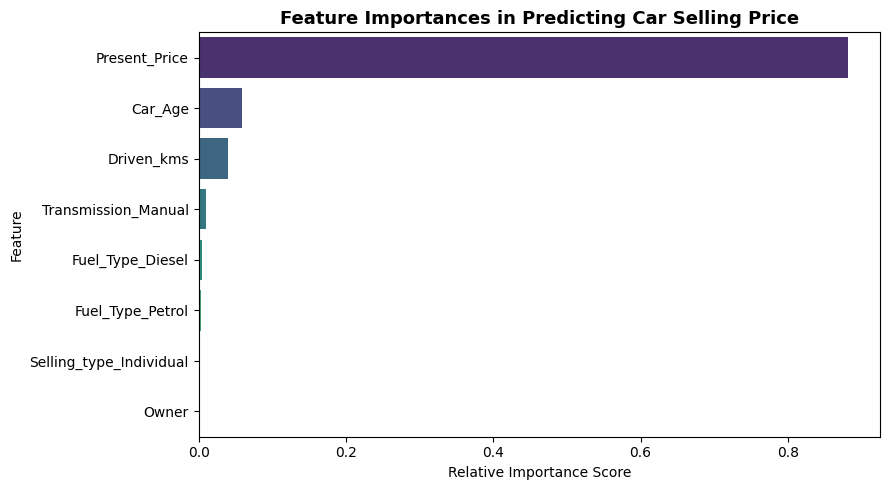

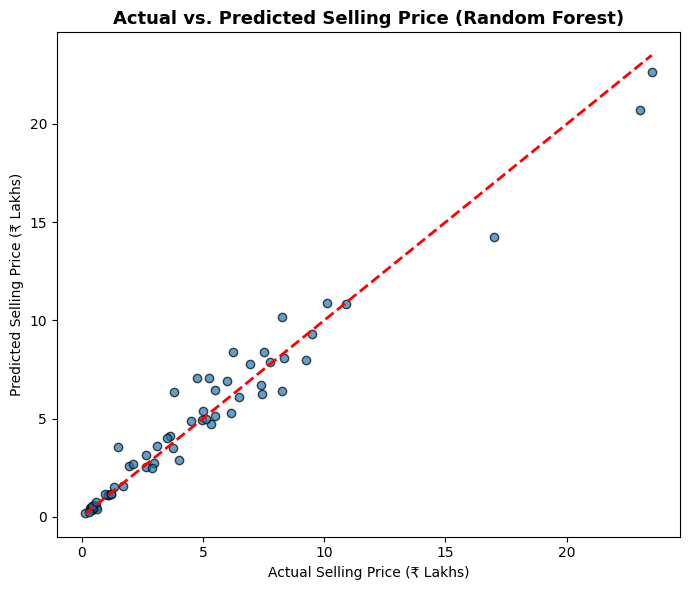

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load Dataset
df = pd.read_csv('car data.csv')

# 2. Feature Engineering & Preprocessing
# Derive vehicle age from manufacture year
dataset_ref_year = df['Year'].max() + 1
df['Car_Age'] = dataset_ref_year - df['Year']

# Drop raw identifier and redundant year column
df_clean = df.drop(columns=['Car_Name', 'Year'])

# Encode categorical features (Fuel_Type, Selling_type, Transmission)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 3. Train-Test Split (80% Train, 20% Test)
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Model Training (Linear Regression & Random Forest)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5. Model Evaluation Metrics
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): ₹{mae:.2f} Lakhs")
    print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f} Lakhs\n")

print_metrics("Linear Regression", y_test, y_pred_lr)
print_metrics("Random Forest Regressor", y_test, y_pred_rf)

# 6. Feature Importance Visualization
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importances in Predicting Car Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 7. Actual vs Predicted Valuation Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, color='#1f77b4', edgecolors='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Selling Price (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Selling Price (₹ Lakhs)')
plt.ylabel('Predicted Selling Price (₹ Lakhs)')
plt.tight_layout()
plt.show()